In [3]:
using MPSKit, TensorKit, Plots, LinearAlgebra, LaTeXStrings

In [4]:
D = 64 # maximum bond dimension

64

In [31]:
function convergence(d_min::Int, d_max::Int)
    for d in d_min:2:d_max
        phi_sq = zeros(ComplexF64, (d, d))
        pi_sq = zeros(ComplexF64, (d, d))
        phi_4 = zeros(ComplexF64, (d, d))
        phi = zeros(ComplexF64, (d, d))
        for i in 2:d
            phi[i, i - 1] = sqrt(i / 2)
            phi[i - 1, i] = sqrt(i / 2)
        end
        for i in 1:d
            if i < d - 1
                phi_sq[i, i + 2] = sqrt(i * (i + 1)) / 2
                phi_sq[i + 2, i] = sqrt(i * (i + 1)) / 2
            end
            phi_sq[i, i] = (2 * i - 1) / 2
        end
        for i in 1:d
            if i < d - 1
                pi_sq[i, i + 2] = - sqrt(i * (i + 1)) / 2
                pi_sq[i + 2, i] = - sqrt(i * (i + 1)) / 2
            end
            pi_sq[i, i] = (2 * i - 1) / 2
        end
        for i in 1:d
            n = i - 1  # occupation number
        
            # diagonal
            phi_4[i, i] = (6 * n^2 + 6 * n + 3) / 4
        
            # connect |n> <-> |n+2>
            if i + 2 <= d
                val = (4 * n + 6) * sqrt((n + 1) * (n + 2)) / 4
                j = i + 2
                phi_4[i, j] = val
                phi_4[j, i] = val   # Hermitian
            end
        
            # connect |n> <-> |n+4>
            if i + 4 <= d
                val = sqrt((n + 1) * (n + 2) * (n + 3) * (n + 4)) / 4
                j = i + 4
                phi_4[i, j] = val
                phi_4[j, i] = val   # Hermitian
            end
        end
        ϕ2 = TensorMap(phi_sq, ℂ^d ← ℂ^d)
        π2 = TensorMap(pi_sq, ℂ^d ← ℂ^d)
        ϕ4 = TensorMap(phi_4, ℂ^d ← ℂ^d)
        ϕ = TensorMap(phi, ℂ^d ← ℂ^d)
        μ0 = 0.3
        κ = 0.1
        λ = 0.0
        infinite_chain = PeriodicVector([ℂ^d])
        ham_onsite = μ0^2 * ϕ2 / 2 + π2 / 2 + λ * ϕ4 / 24 + κ * ϕ2 # on site terms
        ham_bond = -κ * ϕ ⊗ ϕ # bond terms
        H_phi4_infinite = InfiniteMPOHamiltonian(infinite_chain, 1 => ham_onsite, (1, 2) => ham_bond)
        ψ0 = InfiniteMPS(ℂ^d, ℂ^D)
        ψ, _, _ = find_groundstate(ψ0, H_phi4_infinite, VUMPS())
        println(entropy(ψ))
    end
end

convergence (generic function with 1 method)

In [51]:
function EEplot!(d, plt, κ_start, λ_start, κ_grid, λ_grid, κ_step, λ_step, μ0)
    phi_sq = zeros(ComplexF64, (d, d))
    pi_sq = zeros(ComplexF64, (d, d))
    phi_4 = zeros(ComplexF64, (d, d))
    phi = zeros(ComplexF64, (d, d))
    for i in 2:d
        phi[i, i - 1] = sqrt(i / 2)
        phi[i - 1, i] = sqrt(i / 2)
    end
    for i in 1:d
        if i < d - 1
            phi_sq[i, i + 2] = sqrt(i * (i + 1)) / 2
            phi_sq[i + 2, i] = sqrt(i * (i + 1)) / 2
        end
        phi_sq[i, i] = (2 * i - 1) / 2
    end
    for i in 1:d
        if i < d - 1
            pi_sq[i, i + 2] = - sqrt(i * (i + 1)) / 2
            pi_sq[i + 2, i] = - sqrt(i * (i + 1)) / 2
        end
        pi_sq[i, i] = (2 * i - 1) / 2
    end
    for i in 1:d
        n = i - 1  # occupation number
    
        # diagonal
        phi_4[i, i] = (6 * n^2 + 6 * n + 3) / 4
    
        # connect |n> <-> |n+2>
        if i + 2 <= d
            val = (4 * n + 6) * sqrt((n + 1) * (n + 2)) / 4
            j = i + 2
            phi_4[i, j] = val
            phi_4[j, i] = val   # Hermitian
        end
    
        # connect |n> <-> |n+4>
        if i + 4 <= d
            val = sqrt((n + 1) * (n + 2) * (n + 3) * (n + 4)) / 4
            j = i + 4
            phi_4[i, j] = val
            phi_4[j, i] = val   # Hermitian
        end
    end
    ϕ2 = TensorMap(phi_sq, ℂ^d ← ℂ^d)
    π2 = TensorMap(pi_sq, ℂ^d ← ℂ^d)
    ϕ4 = TensorMap(phi_4, ℂ^d ← ℂ^d)
    ϕ = TensorMap(phi, ℂ^d ← ℂ^d)
    κ_max = κ_grid * κ_step
    λ_max = λ_grid * λ_step
    infinite_chain = PeriodicVector([ℂ^d])
    for i in λ_start:λ_grid
    	entropy_vec = zeros(Float64, κ_grid - κ_start + 1) # + 1 since we include 0
    	λ = λ_step * i
    	for j in κ_start:κ_grid
    		κ = κ_step * j
    		println("Currently working with λ = $λ and κ = $κ")
    		ham_onsite = μ0^2 * ϕ2 / 2 + π2 / 2 + λ * ϕ4 / 24 + κ * ϕ2 # on site terms
    		ham_bond = -κ * ϕ ⊗ ϕ # bond terms
    		H_phi4_infinite = InfiniteMPOHamiltonian(infinite_chain, 1 => ham_onsite, (1, 2) => ham_bond)
    		ψ0 = InfiniteMPS(ℂ^d, ℂ^D)
    		ψ, _, _ = find_groundstate(ψ0, H_phi4_infinite, VUMPS(;tol=1e-7))
    		entropy_vec[j - κ_start + 1] = entropy(ψ)[1]
    	end
    	plot!(plt, κ_step * [κ_start:κ_grid], entropy_vec, label=L"\lambda = %$(round(λ, digits=1))")
    	xlabel!(L"\kappa")
    	ylabel!(L"S_{1/2}")
    end
end

EEplot! (generic function with 2 methods)

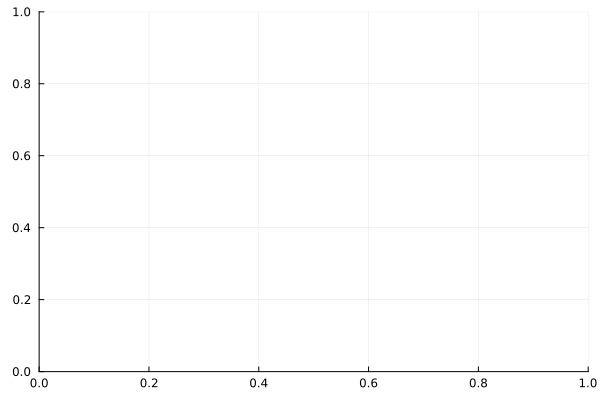

In [81]:
plt = plot(lw=2)

In [82]:
EEplot!(4, plt, 0, 0, 3, 3, 0.1, 0.2, 0.3)

Currently working with λ = 0.0 and κ = 0.0


[ Info: VUMPS init:	obj = +6.502442557853e-01	err = 3.4834e-01
[ Info: VUMPS   1:	obj = +1.846196811947e-01	err = 2.6147447731e-03	time = 0.26 sec
[ Info: VUMPS   2:	obj = +1.846196795650e-01	err = 5.7893579676e-05	time = 0.21 sec
[ Info: VUMPS   3:	obj = +1.846196795602e-01	err = 7.6126344775e-07	time = 0.27 sec


Currently working with λ = 0.0 and κ = 0.1


[ Info: VUMPS conv 4:	obj = +1.846196795602e-01	err = 6.5859273815e-09	time = 1.05 sec
[ Info: VUMPS init:	obj = +6.177209806232e-01	err = 3.7730e-01
[ Info: VUMPS   1:	obj = +2.519389558286e-01	err = 7.5028724932e-02	time = 0.67 sec
[ Info: VUMPS   2:	obj = +2.509351087272e-01	err = 3.3702342759e-03	time = 0.25 sec
[ Info: VUMPS   3:	obj = +2.509332526082e-01	err = 3.6350178282e-05	time = 0.81 sec
[ Info: VUMPS   4:	obj = +2.509332524913e-01	err = 6.0829655392e-06	time = 0.44 sec
[ Info: VUMPS   5:	obj = +2.509332524902e-01	err = 7.5445676418e-07	time = 0.15 sec
[ Info: VUMPS   6:	obj = +2.509332524902e-01	err = 1.0106234767e-07	time = 0.12 sec


Currently working with λ = 0.0 and κ = 0.2


...

[ Info: VUMPS init:	obj = +9.316063006530e-01	err = 3.6745e-01
[ Info: VUMPS   1:	obj = +3.022871495076e-01	err = 6.7264085381e-02	time = 0.20 sec
[ Info: VUMPS   2:	obj = +3.015808646809e-01	err = 4.9820355733e-04	time = 0.19 sec
[ Info: VUMPS   3:	obj = +3.015808505780e-01	err = 4.1261357041e-06	time = 0.29 sec
[ Info: VUMPS   4:	obj = +3.015808505777e-01	err = 3.6619235512e-07	time = 0.21 sec


Currently working with λ = 0.6000000000000001 and κ = 0.2


[ Info: VUMPS conv 5:	obj = +3.015808505777e-01	err = 1.5302939386e-08	time = 1.09 sec
[ Info: VUMPS init:	obj = +8.895099976840e-01	err = 3.7713e-01
[ Info: VUMPS   1:	obj = +3.426629153269e-01	err = 1.7781356787e-01	time = 0.22 sec
[ Info: VUMPS   2:	obj = +3.360063497616e-01	err = 2.8613442989e-02	time = 0.34 sec
[ Info: VUMPS   3:	obj = +3.358183948829e-01	err = 1.3659413194e-03	time = 0.44 sec
[ Info: VUMPS   4:	obj = +3.358180268834e-01	err = 7.8681017329e-05	time = 0.37 sec
[ Info: VUMPS   5:	obj = +3.358180265685e-01	err = 1.4931098704e-05	time = 0.37 sec
[ Info: VUMPS   6:	obj = +3.358180265607e-01	err = 2.4987641390e-06	time = 0.33 sec
[ Info: VUMPS   7:	obj = +3.358180265605e-01	err = 4.5668327879e-07	time = 0.22 sec


Currently working with λ = 0.6000000000000001 and κ = 0.30000000000000004


[ Info: VUMPS conv 8:	obj = +3.358180265605e-01	err = 6.6844699827e-08	time = 2.47 sec
[ Info: VUMPS init:	obj = +8.568786813165e-01	err = 3.8087e-01
[ Info: VUMPS   1:	obj = +3.338812387747e-01	err = 8.5674075168e-02	time = 0.54 sec
[ Info: VUMPS   2:	obj = +3.334418164522e-01	err = 6.7257153642e-03	time = 0.57 sec
[ Info: VUMPS   3:	obj = +3.334395775575e-01	err = 7.3331893587e-04	time = 0.73 sec
[ Info: VUMPS   4:	obj = +3.334395572109e-01	err = 1.4184131834e-04	time = 0.29 sec
[ Info: VUMPS   5:	obj = +3.334395566547e-01	err = 3.3660045340e-05	time = 0.24 sec
[ Info: VUMPS   6:	obj = +3.334395566261e-01	err = 8.5702332345e-06	time = 0.53 sec
[ Info: VUMPS   7:	obj = +3.334395566246e-01	err = 1.8221240118e-06	time = 0.28 sec
[ Info: VUMPS   8:	obj = +3.334395566245e-01	err = 4.3065195997e-07	time = 0.26 sec
[ Info: VUMPS   9:	obj = +3.334395566245e-01	err = 1.1812405048e-07	time = 0.20 sec
[ Info: VUMPS conv 10:	obj = +3.334395566245e-01	err = 3.4909651129e-08	time = 3.81 sec


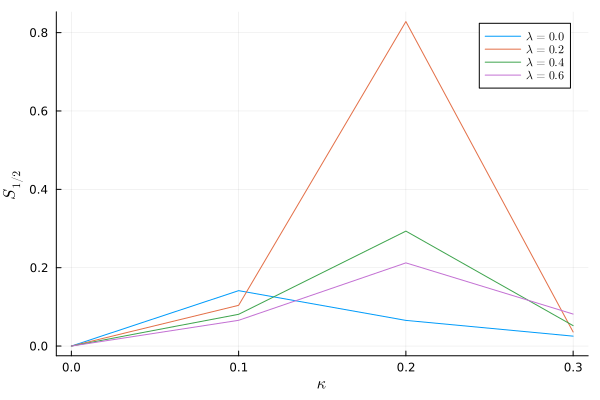

In [83]:
display(plt)

In [85]:
function EEplot!(d, plt, κ_start, λ_start, κ_grid, λ_grid, κ_step, λ_step, μ0)
    phi_sq = zeros(ComplexF64, (d, d))
    pi_sq  = zeros(ComplexF64, (d, d))
    phi_4  = zeros(ComplexF64, (d, d))
    phi    = zeros(ComplexF64, (d, d))

    for i in 2:d
        phi[i, i - 1] = sqrt(i / 2)
        phi[i - 1, i] = sqrt(i / 2)
    end
    for i in 1:d
        if i < d - 1
            phi_sq[i, i + 2] = sqrt(i * (i + 1)) / 2
            phi_sq[i + 2, i] = sqrt(i * (i + 1)) / 2
        end
        phi_sq[i, i] = (2 * i - 1) / 2
    end
    for i in 1:d
        if i < d - 1
            pi_sq[i, i + 2] = -sqrt(i * (i + 1)) / 2
            pi_sq[i + 2, i] = -sqrt(i * (i + 1)) / 2
        end
        pi_sq[i, i] = (2 * i - 1) / 2
    end
    for i in 1:d
        n = i - 1
        phi_4[i, i] = (6n^2 + 6n + 3) / 4
        if i + 2 <= d
            val = (4n + 6) * sqrt((n + 1) * (n + 2)) / 4
            j = i + 2
            phi_4[i, j] = val
            phi_4[j, i] = val
        end
        if i + 4 <= d
            val = sqrt((n + 1) * (n + 2) * (n + 3) * (n + 4)) / 4
            j = i + 4
            phi_4[i, j] = val
            phi_4[j, i] = val
        end
    end

    ϕ2 = TensorMap(phi_sq, ℂ^d ← ℂ^d)
    π2 = TensorMap(pi_sq,  ℂ^d ← ℂ^d)
    ϕ4 = TensorMap(phi_4,  ℂ^d ← ℂ^d)
    ϕ  = TensorMap(phi,    ℂ^d ← ℂ^d)

    κ_max = κ_grid * κ_step
    infinite_chain = PeriodicVector([ℂ^d])

    # --- custom κ grid: finer between 0 and 0.3 ---
    κ_fine_max  = 0.3
    κ_fine_step = κ_step / 10  # have to be finer near the critical point

    κ_vals_fine   = collect(0.0:κ_fine_step:κ_fine_max)
    κ_vals_coarse = collect(κ_fine_max + κ_step : κ_step : κ_max)
    κ_vals        = vcat(κ_vals_fine, κ_vals_coarse)
    # ------------------------------------------------

    for i in λ_start:λ_grid
        λ = λ_step * i
        entropy_vec = zeros(Float64, length(κ_vals))

        for (idx, κ) in enumerate(κ_vals)
            println("Currently working with λ = $λ and κ = $κ")
            ham_onsite = μ0^2 * ϕ2 / 2 + π2 / 2 + λ * ϕ4 / 24 + κ * ϕ2
            ham_bond   = -κ * ϕ ⊗ ϕ
            H_phi4_infinite = InfiniteMPOHamiltonian(infinite_chain,
                                                     1 => ham_onsite,
                                                     (1, 2) => ham_bond)
            ψ0 = InfiniteMPS(ℂ^d, ℂ^D)
            ψ, _, _ = find_groundstate(ψ0, H_phi4_infinite, VUMPS(; tol=1e-7))
            entropy_vec[idx] = entropy(ψ)[1]
        end

        plot!(plt, κ_vals, entropy_vec,
              label = L"\lambda = %$(round(λ, digits=1))")
        xlabel!(L"\kappa")
        ylabel!(L"S_{1/2}")
    end
end


EEplot! (generic function with 2 methods)

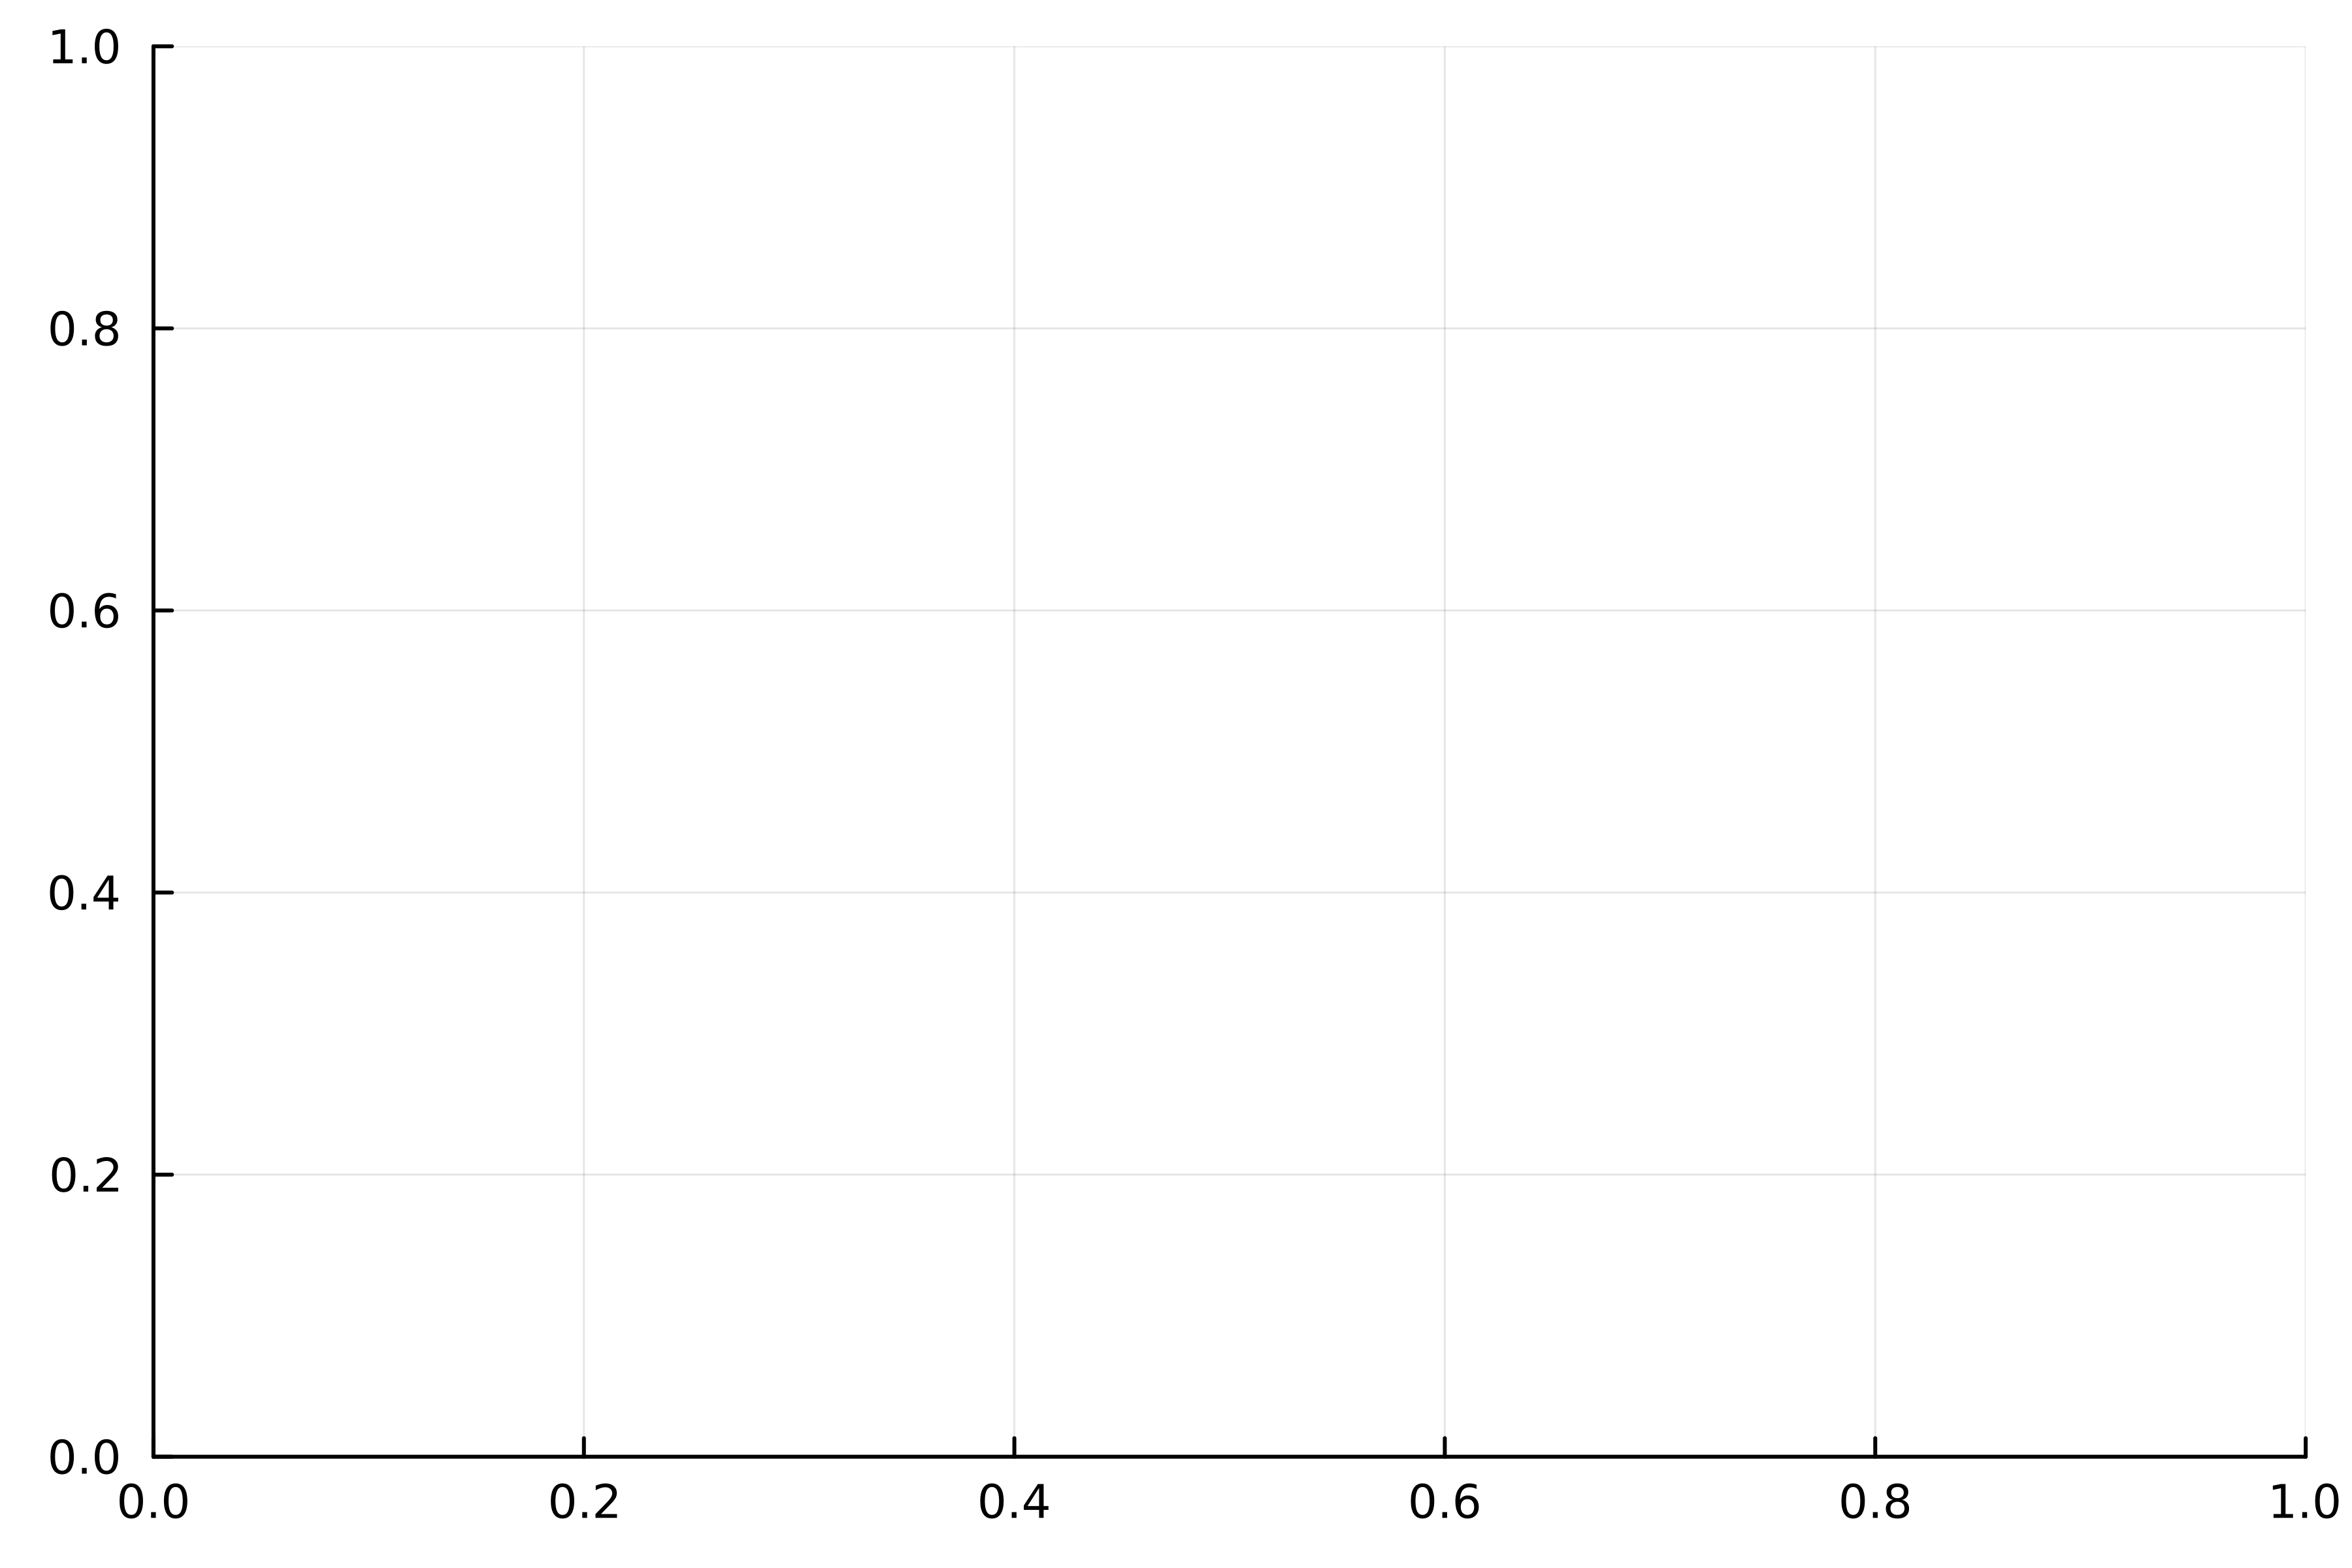

In [86]:
plt = plot(lw=2, dpi=600)

In [92]:
d = 4
κ_start = 0
λ_start = 0
κ_grid = 10
λ_grid = 4
κ_step = 0.1
λ_step = 0.2
μ0 = 0.3

0.3

In [91]:
EEplot!(d, plt, κ_start, λ_start, κ_grid, λ_grid, κ_step, λ_step, μ0)

LoadError: UndefVarError: `d` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

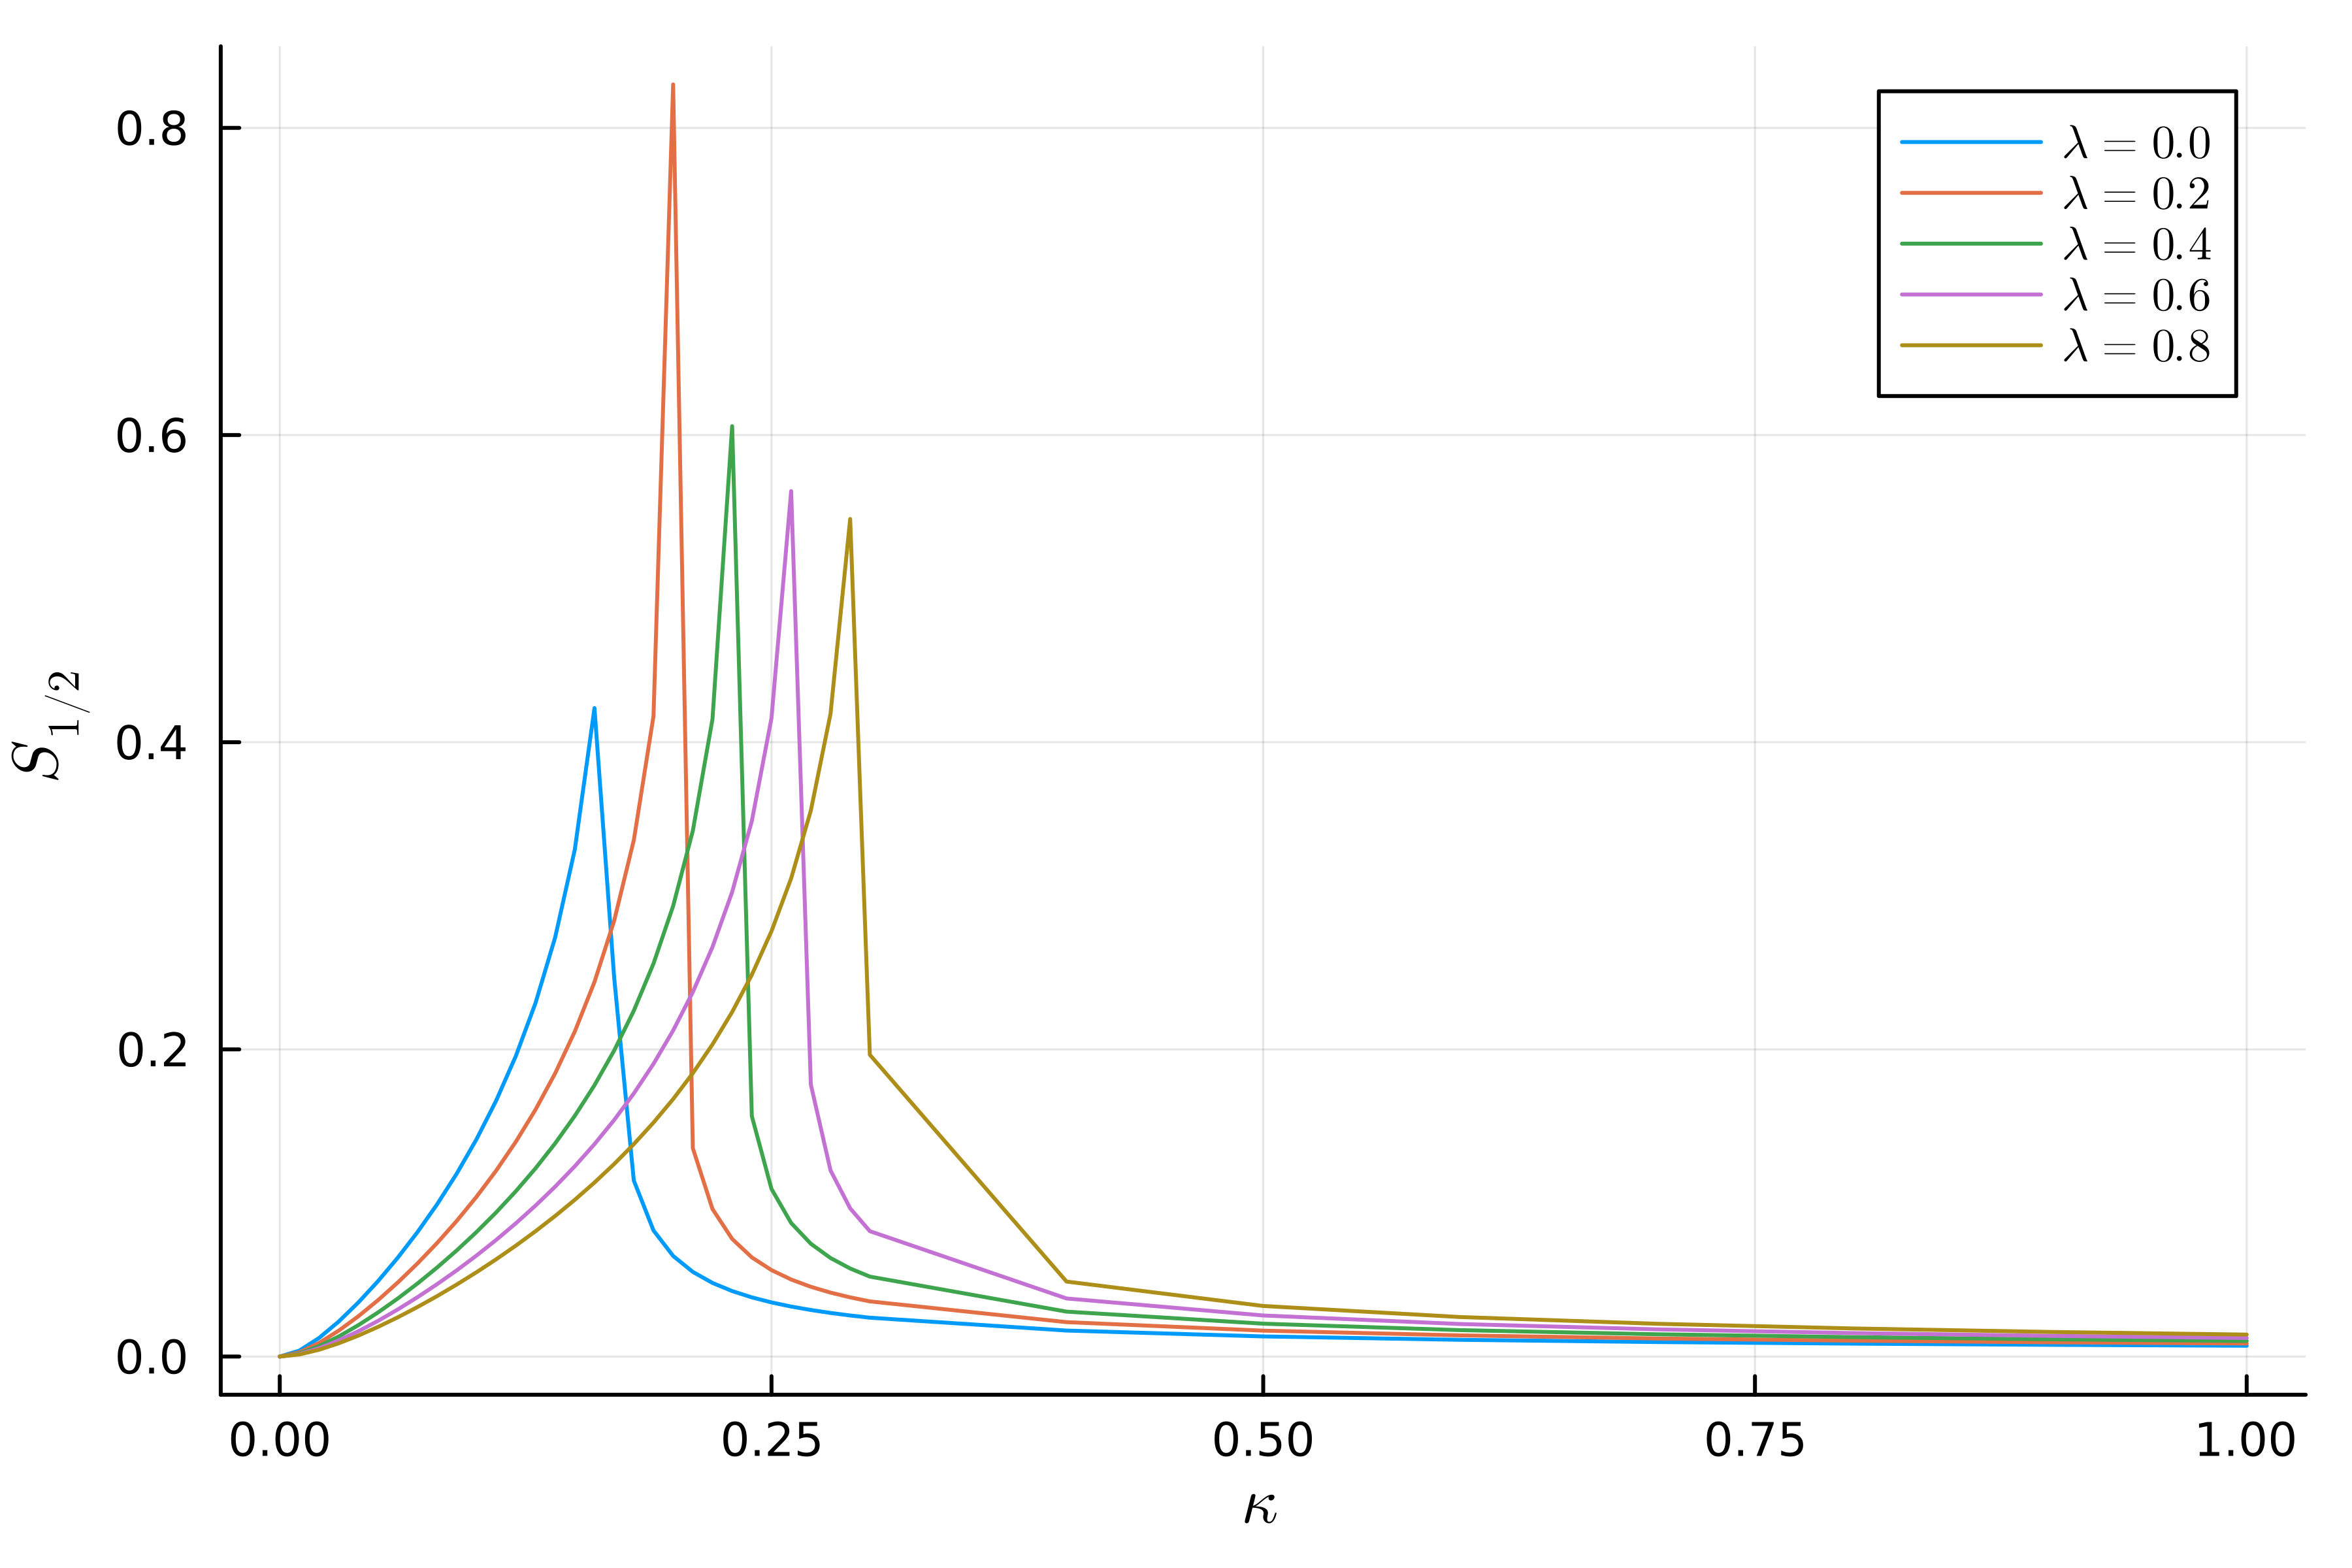

In [88]:
plt

In [94]:
savefig("phi4gsentanglement_d$(d)_D$(D)_mu$(μ0).png")

"/home/ujjwal/MPSJulia/phi4/phi4gsentanglement_d4_D64_mu0.3.png"

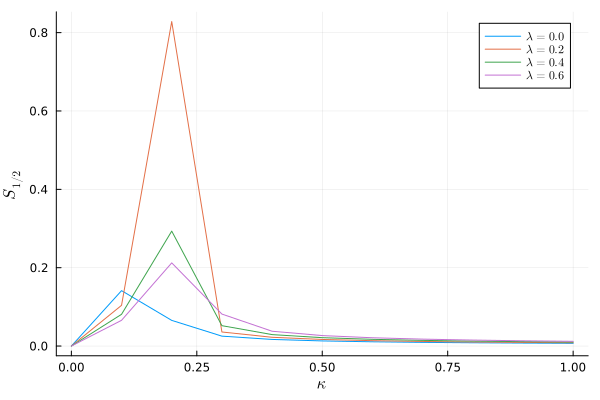

In [63]:
plot!(lw=200)